Chat GPT version of the MAFFT code for step 10 of the homework assignment.

In [ ]:
# ============================================================
# MAFFT Multiple Sequence Alignment in R / Google Colab
#
# Input:
#   /content/P450.fasta
#
# Output:
#   /content/P450_aligned.fasta
#
# The input contains protein sequences.
# ============================================================


# ------------------------------------------------------------
# 1. Install Biostrings
# ------------------------------------------------------------

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages(
    "BiocManager",
    repos = "https://cloud.r-project.org"
  )
}

if (!requireNamespace("Biostrings", quietly = TRUE)) {
  BiocManager::install(
    "Biostrings",
    ask = FALSE,
    update = FALSE
  )
}

library(Biostrings)


# ------------------------------------------------------------
# 2. Define input and output files
# ------------------------------------------------------------

input_file <- "/content/P450.fasta"
output_file <- "/content/P450_aligned.fasta"


# ------------------------------------------------------------
# 3. Check that the input file exists
# ------------------------------------------------------------

if (!file.exists(input_file)) {
  stop(
    paste(
      "ERROR: Input file not found:",
      input_file
    )
  )
}

cat("Input file found:", input_file, "\n")


# ------------------------------------------------------------
# 4. Install MAFFT if necessary
# ------------------------------------------------------------

mafft_path <- Sys.which("mafft")

if (mafft_path == "") {

  cat("MAFFT is not installed.\n")
  cat("Installing MAFFT...\n\n")

  system(
    "apt-get update -qq && apt-get install -y mafft"
  )

  mafft_path <- Sys.which("mafft")
}


# ------------------------------------------------------------
# 5. Verify MAFFT installation
# ------------------------------------------------------------

if (mafft_path == "") {
  stop(
    "ERROR: MAFFT could not be installed or found."
  )
}

cat("MAFFT executable:", mafft_path, "\n")


# ------------------------------------------------------------
# 6. Read the input protein FASTA
# ------------------------------------------------------------

cat("\nReading protein sequences...\n")

sequences <- readAAStringSet(input_file)

cat(
  "Number of sequences:",
  length(sequences),
  "\n"
)


# ------------------------------------------------------------
# 7. Check the input sequences
# ------------------------------------------------------------

cat(
  "Original sequence lengths:\n"
)

print(
  summary(
    width(sequences)
  )
)


# ------------------------------------------------------------
# 8. Run MAFFT
# ------------------------------------------------------------

cat("\n============================================\n")
cat("Starting MAFFT alignment...\n")
cat("============================================\n\n")

# Remove an old output file if it exists
if (file.exists(output_file)) {
  file.remove(output_file)
}

# Run MAFFT.
#
# --auto:
#   MAFFT automatically chooses an appropriate
#   alignment strategy.
#
# The shell redirection ">" sends ONLY the alignment
# to the FASTA file.
#
# "2>" sends MAFFT progress/error messages to a
# separate log file.

mafft_command <- paste(
  shQuote(mafft_path),
  "--auto",
  shQuote(input_file),
  ">",
  shQuote(output_file),
  "2>",
  shQuote("/content/mafft_error.log")
)

status <- system(
  mafft_command
)


# ------------------------------------------------------------
# 9. Check whether MAFFT completed successfully
# ------------------------------------------------------------

if (status != 0) {

  cat("\nMAFFT returned an error.\n")

  if (file.exists("/content/mafft_error.log")) {
    cat("\nMAFFT error log:\n")
    cat(
      readLines(
        "/content/mafft_error.log"
      ),
      sep = "\n"
    )
  }

  stop("MAFFT alignment failed.")

}


# ------------------------------------------------------------
# 10. Check that the alignment file exists
# ------------------------------------------------------------

if (!file.exists(output_file)) {
  stop(
    "ERROR: MAFFT finished but the output FASTA was not created."
  )
}


# ------------------------------------------------------------
# 11. Check that the output file is not empty
# ------------------------------------------------------------

if (file.info(output_file)$size == 0) {
  stop(
    "ERROR: The MAFFT output file is empty."
  )
}


cat("\nMAFFT completed successfully!\n")
cat(
  "Alignment saved to:",
  output_file,
  "\n"
)


# ------------------------------------------------------------
# 12. Read the aligned FASTA back into R
# ------------------------------------------------------------

cat("\nReading aligned FASTA into R...\n")

alignment <- readAAStringSet(
  output_file
)


# ------------------------------------------------------------
# 13. Verify the alignment
# ------------------------------------------------------------

cat("\n============================================\n")
cat("ALIGNMENT SUMMARY\n")
cat("============================================\n")

cat(
  "Number of aligned sequences:",
  length(alignment),
  "\n"
)

aligned_lengths <- width(alignment)

cat(
  "Aligned sequence length:",
  unique(aligned_lengths),
  "\n"
)


# Check whether all sequences have identical lengths

if (length(unique(aligned_lengths)) == 1) {

  cat(
    "All sequences have the same aligned length: YES\n"
  )

} else {

  cat(
    "WARNING: Aligned sequences have different lengths.\n"
  )

}


# ------------------------------------------------------------
# 14. Display sequence names
# ------------------------------------------------------------

cat("\nSequence names:\n")

print(
  names(alignment)
)


# ------------------------------------------------------------
# 15. Display the first few aligned sequences
# ------------------------------------------------------------

cat("\n============================================\n")
cat("FIRST ALIGNED SEQUENCES\n")
cat("============================================\n\n")

print(
  alignment[1:min(5, length(alignment))]
)


# ------------------------------------------------------------
# 16. Display the output file location
# ------------------------------------------------------------

cat("\n============================================\n")
cat("DONE\n")
cat("============================================\n")

cat(
  "Your MAFFT alignment is here:\n",
  output_file,
  "\n\n"
)

cat(
  "You can download this file from the Colab file browser:\n",
  "/content/P450_aligned.fasta\n"
)



Input file found: /content/P450.fasta 
MAFFT executable: /usr/bin/mafft 

Reading protein sequences...
Number of sequences: 129 
Original sequence lengths:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  163.0   491.0   501.0   521.8   519.0  1390.0 

Starting MAFFT alignment...



[1] TRUE


MAFFT completed successfully!
Alignment saved to: /content/P450_aligned.fasta 

Reading aligned FASTA into R...

ALIGNMENT SUMMARY
Number of aligned sequences: 129 
Aligned sequence length: 2871 
All sequences have the same aligned length: YES

Sequence names:
  [1] "gi|33113212|gb|AAP94192.1| cytochrome P450 monooxygenase [Tribolium castaneum]"                            
  [2] "gi|33113213|gb|AAP94193.1| cytochrome P450 monooxygenase [Tribolium castaneum]"                            
  [3] "gi|167003806|ref|NP_001107791.1| cytochrome P450 monooxygenase [Tribolium castaneum]"                      
  [4] "gi|167466280|ref|NP_001107860.1| cytochrome P450 monooxigenase CYP4G7 [Tribolium castaneum]"               
  [5] "gi|189238170|ref|XP_973400.2| PREDICTED: similar to cytochrome P450 [Tribolium castaneum]"                 
  [6] "gi|189240531|ref|XP_972348.2| PREDICTED: similar to cytochrome P450 monooxygenase [Tribolium castaneum]"   
  [7] "gi|189240561|ref|XP_973646.2| PREDICTED: 

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘fastmatch’, ‘igraph’, ‘quadprog’




129 sequences; alignment length 2871 
Calculating pairwise p-distances...
Building Neighbor-Joining tree...
Midpoint rooting tree...
Saved Newick -> /content/gene_tree_nj.newick 
Level 3 contains 2 anchor nodes.
Creating circular tree image...


agg_record_1b5b40647be4 
                      2


TREE ANALYSIS COMPLETE

Sequences: 129 
Alignment length: 2871 amino acids
Tree tips: 129 
Tree rooted: TRUE 

Newick file:
 /content/gene_tree_nj.newick 

Circular PNG:
 /content/gene_tree_circular.png 

Open the Colab Files panel and download:
 gene_tree_circular.png


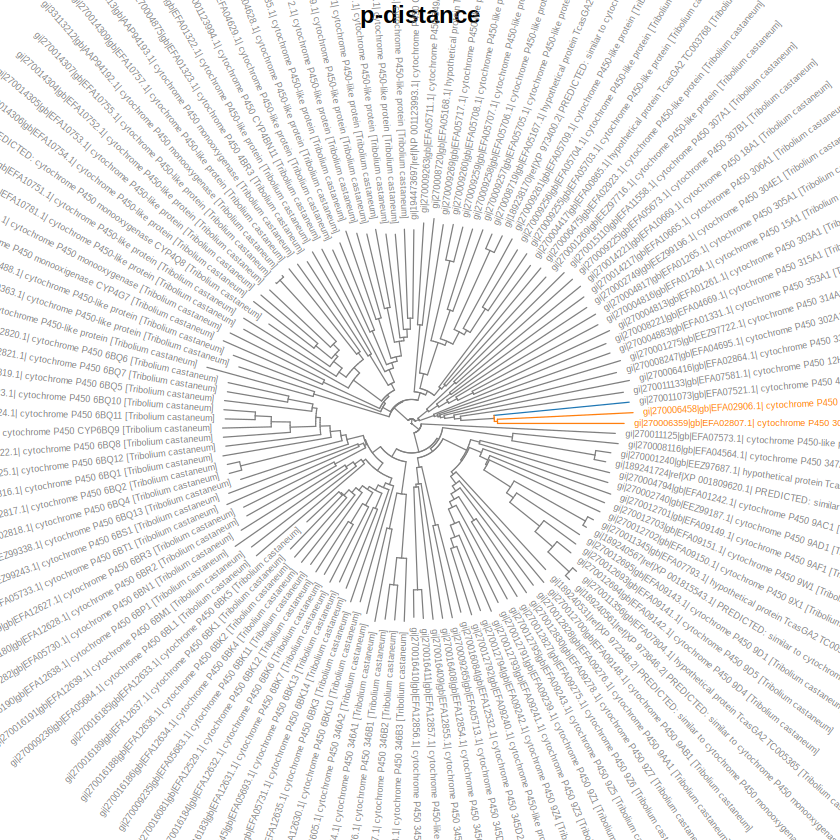

In [ ]:
# ============================================================
# P450 CIRCULAR NEIGHBOR-JOINING TREE
#
# Input:
#   /content/P450_aligned.fasta
#
# Outputs:
#   /content/gene_tree_nj.newick
#   /content/gene_tree_circular.png
# ============================================================


# ------------------------------------------------------------
# 1. Install required packages
# ------------------------------------------------------------

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages(
    "BiocManager",
    repos = "https://cloud.r-project.org"
  )
}

if (!requireNamespace("Biostrings", quietly = TRUE)) {
  BiocManager::install(
    "Biostrings",
    ask = FALSE,
    update = FALSE
  )
}

if (!requireNamespace("ape", quietly = TRUE)) {
  install.packages(
    "ape",
    repos = "https://cloud.r-project.org"
  )
}

if (!requireNamespace("phangorn", quietly = TRUE)) {
  install.packages(
    "phangorn",
    repos = "https://cloud.r-project.org"
  )
}


# ------------------------------------------------------------
# 2. Load packages
# ------------------------------------------------------------

library(Biostrings)
library(ape)
library(phangorn)


# ------------------------------------------------------------
# 3. File paths
# ------------------------------------------------------------

msa_path <- "/content/P450_aligned.fasta"

newick_path <- "/content/gene_tree_nj.newick"

png_path <- "/content/gene_tree_circular.png"


# ------------------------------------------------------------
# 4. Read MAFFT alignment
# ------------------------------------------------------------

if (!file.exists(msa_path)) {
  stop(
    paste(
      "Alignment file not found:",
      msa_path
    )
  )
}

aln <- readAAStringSet(msa_path)

ids <- names(aln)

seqs <- as.character(aln)

N <- length(seqs)

alignment_length <- width(aln)[1]

cat(
  N,
  "sequences; alignment length",
  alignment_length,
  "\n"
)


# ------------------------------------------------------------
# 5. Pairwise p-distance function
# ------------------------------------------------------------

pairwise_pdist <- function(A, B) {

  A <- strsplit(A, "")[[1]]
  B <- strsplit(B, "")[[1]]

  valid <- (
    A != "-" &
    B != "-"
  )

  denom <- sum(valid)

  if (denom == 0) {
    return(1.0)
  }

  identity <- sum(
    A[valid] == B[valid]
  ) / denom

  1.0 - identity
}


# ------------------------------------------------------------
# 6. Calculate pairwise distance matrix
# ------------------------------------------------------------

cat(
  "Calculating pairwise p-distances...\n"
)

dm_mat <- matrix(
  0,
  nrow = N,
  ncol = N
)

rownames(dm_mat) <- ids
colnames(dm_mat) <- ids


for (i in seq_len(N - 1)) {

  for (j in (i + 1):N) {

    d <- pairwise_pdist(
      seqs[i],
      seqs[j]
    )

    dm_mat[i, j] <- d
    dm_mat[j, i] <- d
  }
}


dm <- as.dist(dm_mat)


# ------------------------------------------------------------
# 7. Neighbor-Joining tree
# ------------------------------------------------------------

cat(
  "Building Neighbor-Joining tree...\n"
)

tree <- nj(dm)


# ------------------------------------------------------------
# 8. Midpoint root
# ------------------------------------------------------------

cat(
  "Midpoint rooting tree...\n"
)

tree <- phangorn::midpoint(
  tree
)


# ------------------------------------------------------------
# 9. Save Newick tree
# ------------------------------------------------------------

write.tree(
  tree,
  file = newick_path
)

cat(
  "Saved Newick ->",
  newick_path,
  "\n"
)


# ------------------------------------------------------------
# 10. Define colors
# ------------------------------------------------------------

# Similar to matplotlib's tab10 palette

tab10 <- c(
  "#1F77B4",
  "#FF7F0E",
  "#2CA02C",
  "#D62728",
  "#9467BD",
  "#8C564B",
  "#E377C2",
  "#7F7F7F",
  "#BCBD22",
  "#17BECF"
)


# ------------------------------------------------------------
# 11. Determine topological levels
# ------------------------------------------------------------

# Number of nodes
total_nodes <- Ntip(tree) + tree$Nnode

node_level <- rep(
  NA_integer_,
  total_nodes
)

# Find root
root <- if (!is.null(tree$root)) {
  tree$root
} else {
  total_nodes
}

node_level[root] <- 0


# Propagate levels from root
repeat {

  changed <- FALSE

  for (k in seq_len(nrow(tree$edge))) {

    parent <- tree$edge[k, 1]
    child <- tree$edge[k, 2]

    if (!is.na(node_level[parent])) {

      new_level <- node_level[parent] + 1

      if (is.na(node_level[child])) {

        node_level[child] <- new_level

        changed <- TRUE

      }
    }
  }

  if (!changed) {
    break
  }
}


# ------------------------------------------------------------
# 12. Select the level to color
# ------------------------------------------------------------

L <- 3

anchors <- which(
  node_level == L
)

cat(
  "Level",
  L,
  "contains",
  length(anchors),
  "anchor nodes.\n"
)


# ------------------------------------------------------------
# 13. Find descendants of a node
# ------------------------------------------------------------

get_descendants <- function(
  tree,
  node
) {

  children <- tree$edge[
    tree$edge[, 1] == node,
    2
  ]

  if (length(children) == 0) {
    return(integer(0))
  }

  descendants <- children

  for (child in children) {

    descendants <- c(
      descendants,
      get_descendants(
        tree,
        child
      )
    )
  }

  unique(descendants)
}


# ------------------------------------------------------------
# 14. Assign edge colors
# ------------------------------------------------------------

edge_colors <- rep(
  "grey50",
  nrow(tree$edge)
)

tip_colors <- rep(
  "grey50",
  Ntip(tree)
)


for (i in seq_along(anchors)) {

  anchor <- anchors[i]

  col <- tab10[
    ((i - 1) %% length(tab10)) + 1
  ]

  descendants <- get_descendants(
    tree,
    anchor
  )

  subtree_nodes <- c(
    anchor,
    descendants
  )


  # Color edges belonging to this subtree

  for (k in seq_len(nrow(tree$edge))) {

    child <- tree$edge[k, 2]

    if (child %in% subtree_nodes) {

      edge_colors[k] <- col
    }
  }


  # Color descendant tips

  descendant_tips <- descendants[
    descendants <= Ntip(tree)
  ]

  if (length(descendant_tips) > 0) {

    tip_colors[descendant_tips] <- col

  }
}


# ------------------------------------------------------------
# 15. Save circular tree as high-resolution PNG
# ------------------------------------------------------------

cat(
  "Creating circular tree image...\n"
)

png(
  filename = png_path,
  width = 4000,
  height = 4000,
  res = 300
)


par(
  mar = c(
    1,
    1,
    4,
    1
  )
)


# ------------------------------------------------------------
# 16. Draw circular/fan tree
# ------------------------------------------------------------

plot.phylo(
  tree,
  type = "fan",
  use.edge.length = TRUE,
  show.tip.label = TRUE,
  tip.color = tip_colors,
  edge.color = edge_colors,
  edge.width = 1,
  cex = 0.45,
  label.offset = 0.02,
  no.margin = TRUE,
  font = 1,
  main = "Neighbor-Joining P450 Protein Tree\np-distance"
)


dev.off()


# ------------------------------------------------------------
# 17. Display tree in R
# ------------------------------------------------------------

plot.phylo(
  tree,
  type = "fan",
  use.edge.length = TRUE,
  show.tip.label = TRUE,
  tip.color = tip_colors,
  edge.color = edge_colors,
  edge.width = 1,
  cex = 0.45,
  label.offset = 0.02,
  no.margin = TRUE,
  font = 1,
  main = "Neighbor-Joining P450 Protein Tree\np-distance"
)


# ------------------------------------------------------------
# 18. Final information
# ------------------------------------------------------------

cat("\n")
cat("============================================\n")
cat("TREE ANALYSIS COMPLETE\n")
cat("============================================\n\n")

cat(
  "Sequences:",
  N,
  "\n"
)

cat(
  "Alignment length:",
  alignment_length,
  "amino acids\n"
)

cat(
  "Tree tips:",
  Ntip(tree),
  "\n"
)

cat(
  "Tree rooted:",
  is.rooted(tree),
  "\n\n"
)

cat(
  "Newick file:\n",
  newick_path,
  "\n\n"
)

cat(
  "Circular PNG:\n",
  png_path,
  "\n\n"
)

cat(
  "Open the Colab Files panel and download:\n",
  "gene_tree_circular.png\n"
)


P450 DOT-PLOT ANALYSIS

Reading alignment...
Number of sequences: 129 
Alignment length: 2871 

Removing columns that contain only gaps...
Original length: 2871 
Trimmed length: 2871 
Columns removed: 0 

Trimmed alignment saved:
 /content/P450_trimmed_aln.fasta 

Calculating pairwise percent identities...

TOP 16 SEQUENCE PAIRS

01: 99.4% identity
    gi|33113212|gb|AAP94192.1| cytochrome P450 monooxygenase [Tribolium castaneum]
    gi|270014307|gb|EFA10755.1| cytochrome P450-like protein [Tribolium castaneum]

02: 98.0% identity
    gi|189240567|ref|XP_001815543.1| PREDICTED: similar to cytochrome P450 monooxygenase [Tribolium castaneum]
    gi|270011345|gb|EFA07793.1| hypothetical protein TcasGA2_TC005353 [Tribolium castaneum]

03: 97.9% identity
    gi|189240561|ref|XP_973646.2| PREDICTED: similar to cytochrome P450 monooxygenase [Tribolium castaneum]
    gi|270011356|gb|EFA07804.1| hypothetical protein TcasGA2_TC005365 [Tribolium castaneum]

04: 95.0% identity
    gi|270006369|gb|

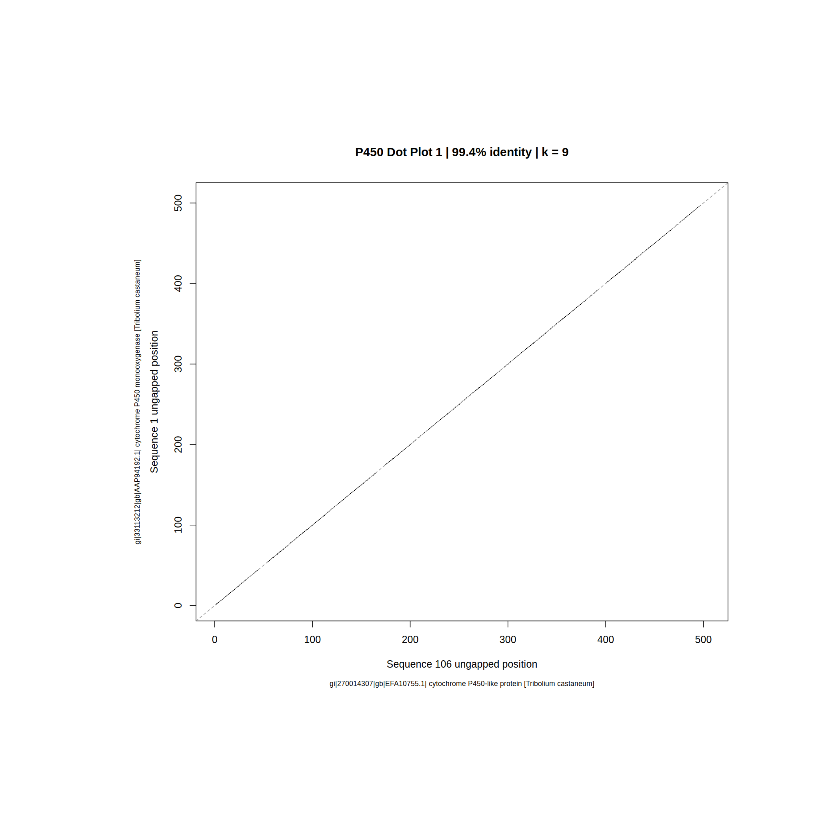


--------------------------------------------
DOT PLOT 3
--------------------------------------------


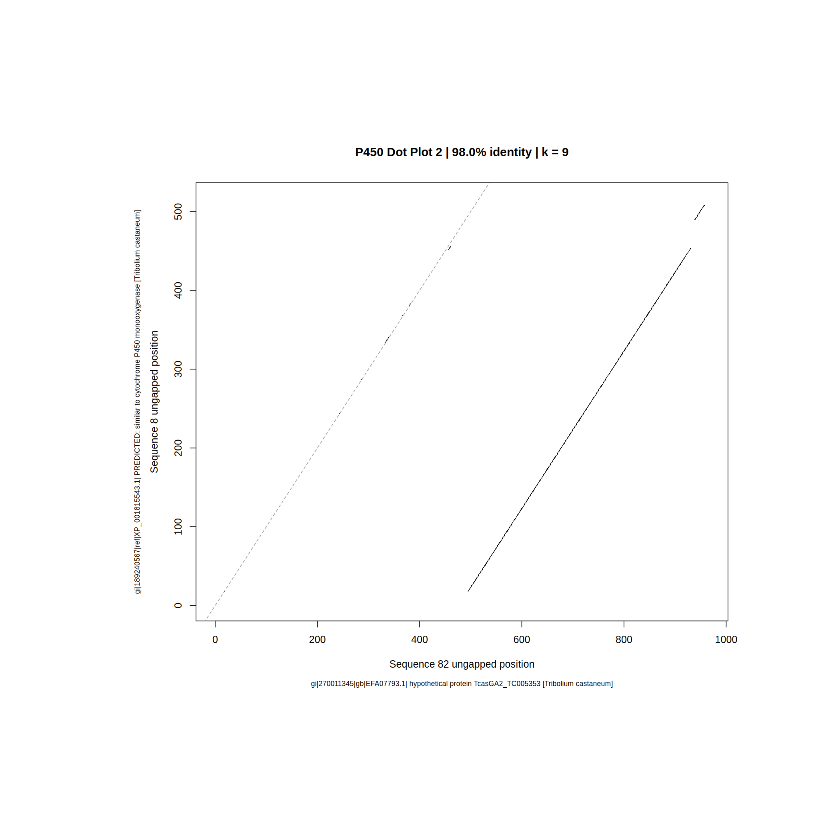


--------------------------------------------
DOT PLOT 4
--------------------------------------------


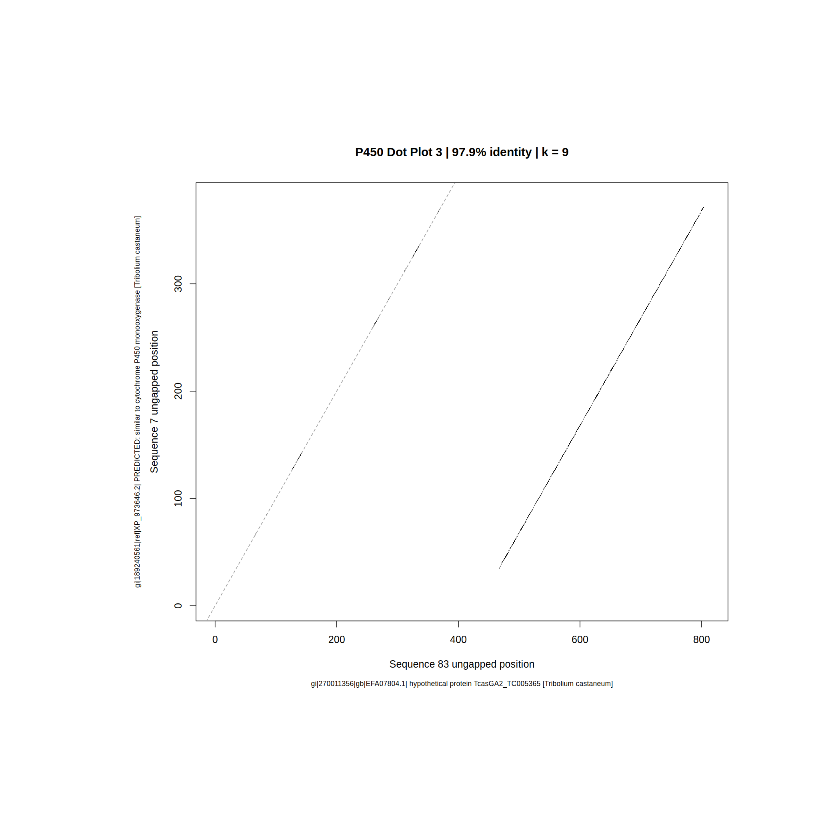


--------------------------------------------
DOT PLOT 5
--------------------------------------------


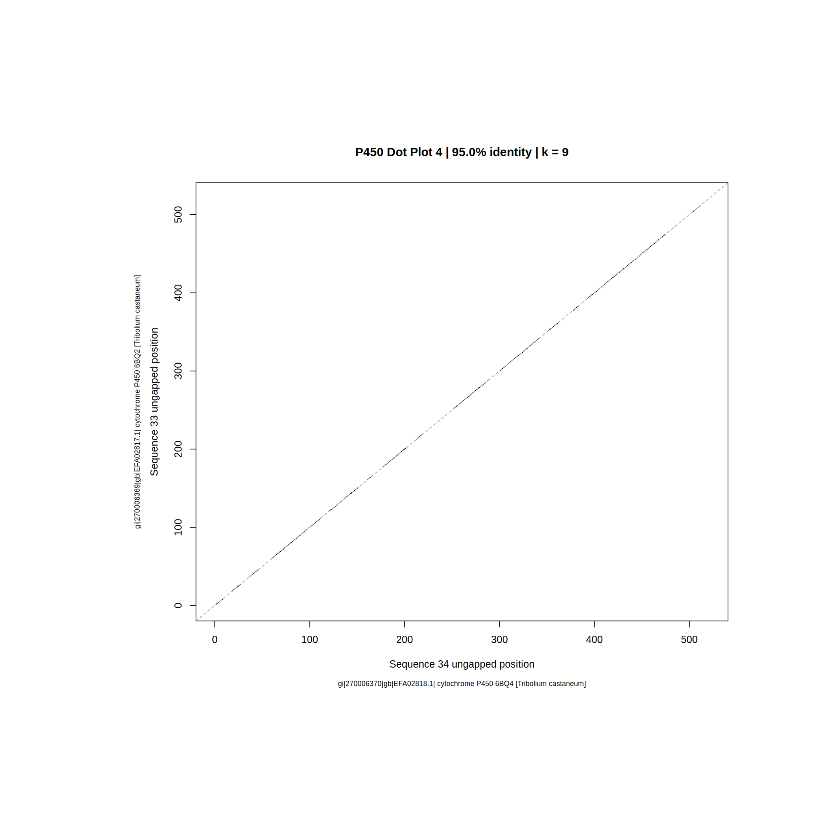


--------------------------------------------
DOT PLOT 6
--------------------------------------------


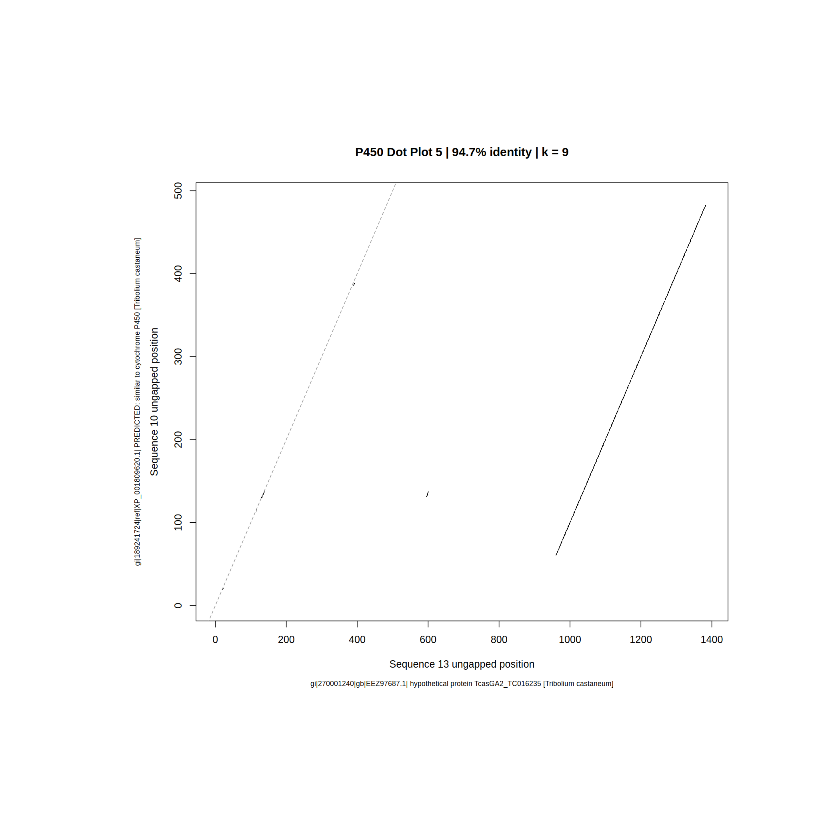


--------------------------------------------
DOT PLOT 7
--------------------------------------------


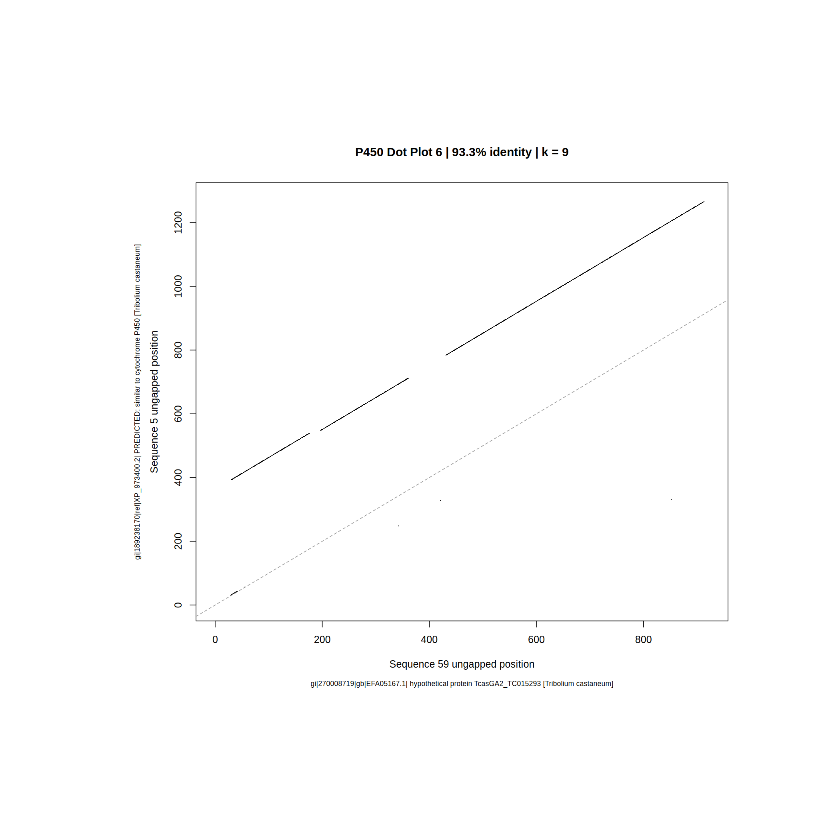


--------------------------------------------
DOT PLOT 8
--------------------------------------------


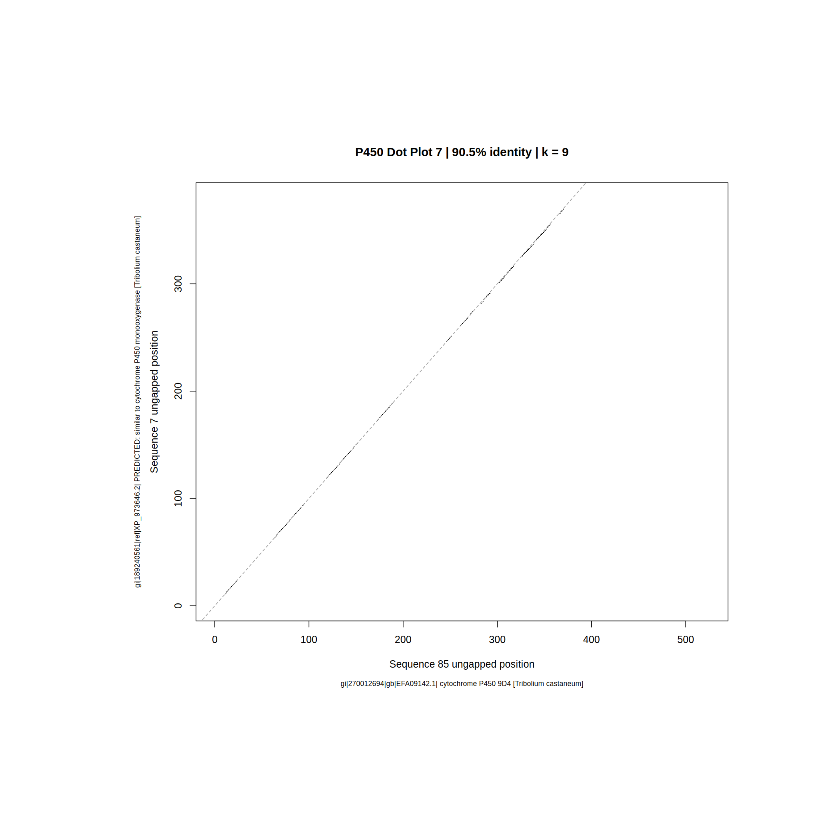


--------------------------------------------
DOT PLOT 9
--------------------------------------------


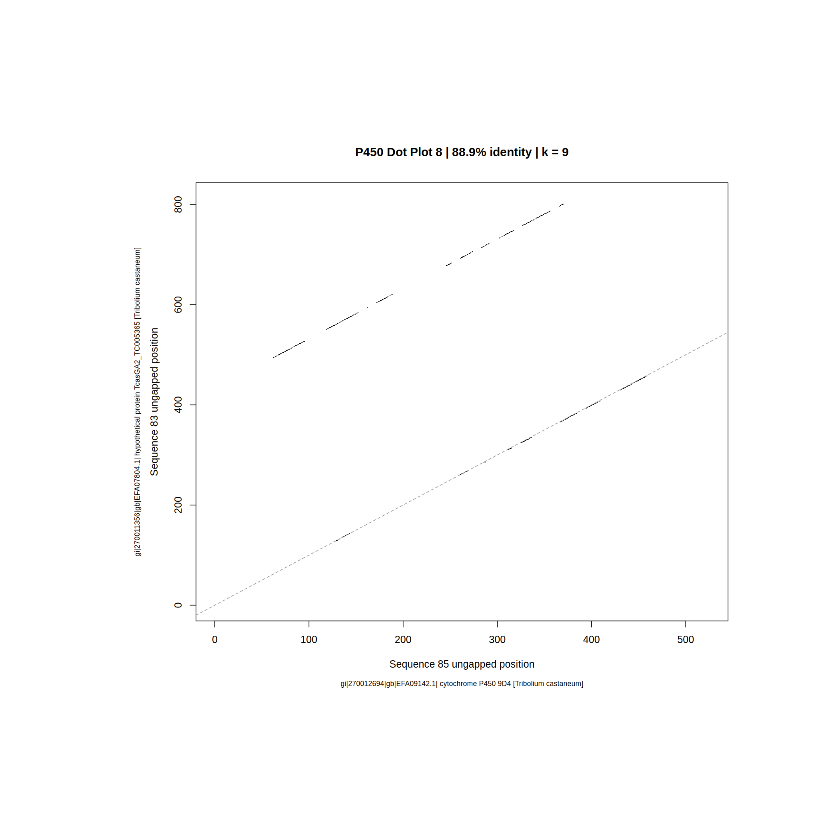


--------------------------------------------
DOT PLOT 10
--------------------------------------------


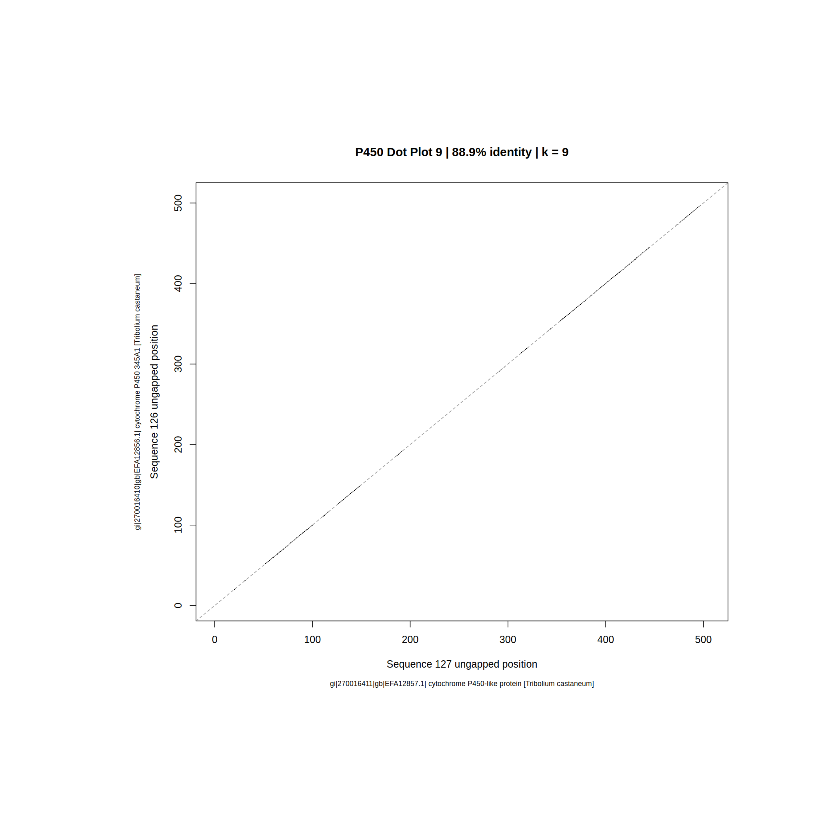


--------------------------------------------
DOT PLOT 11
--------------------------------------------


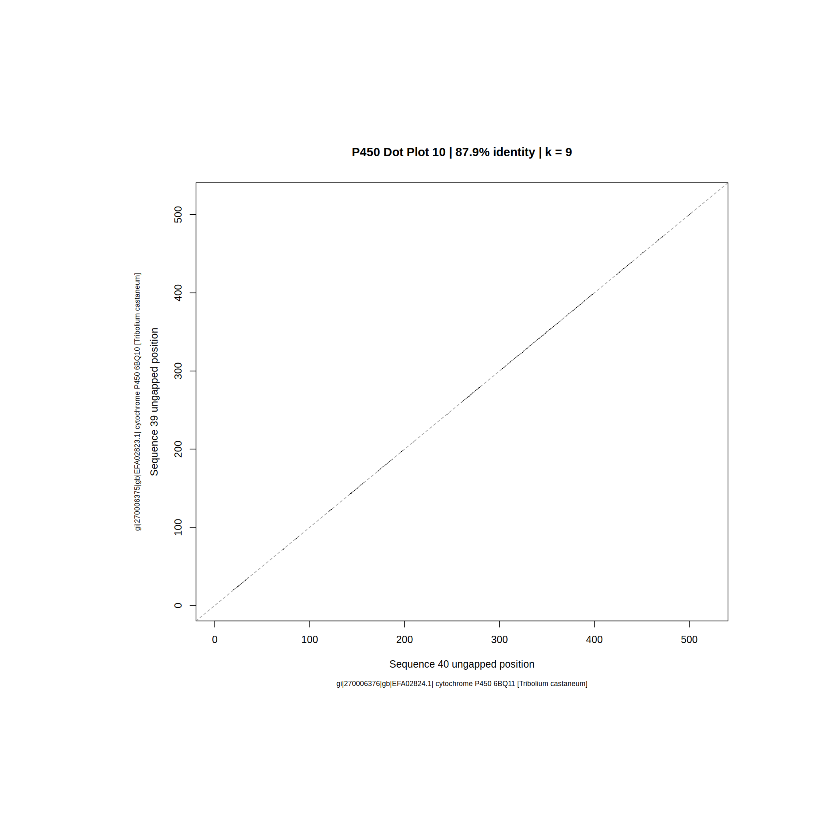


--------------------------------------------
DOT PLOT 12
--------------------------------------------


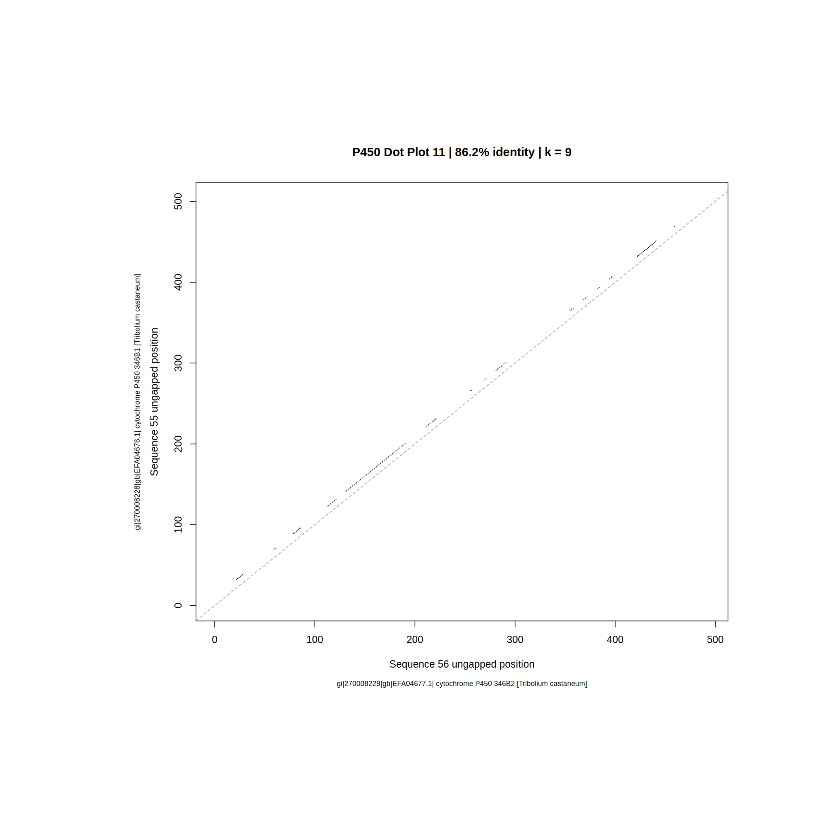


--------------------------------------------
DOT PLOT 13
--------------------------------------------


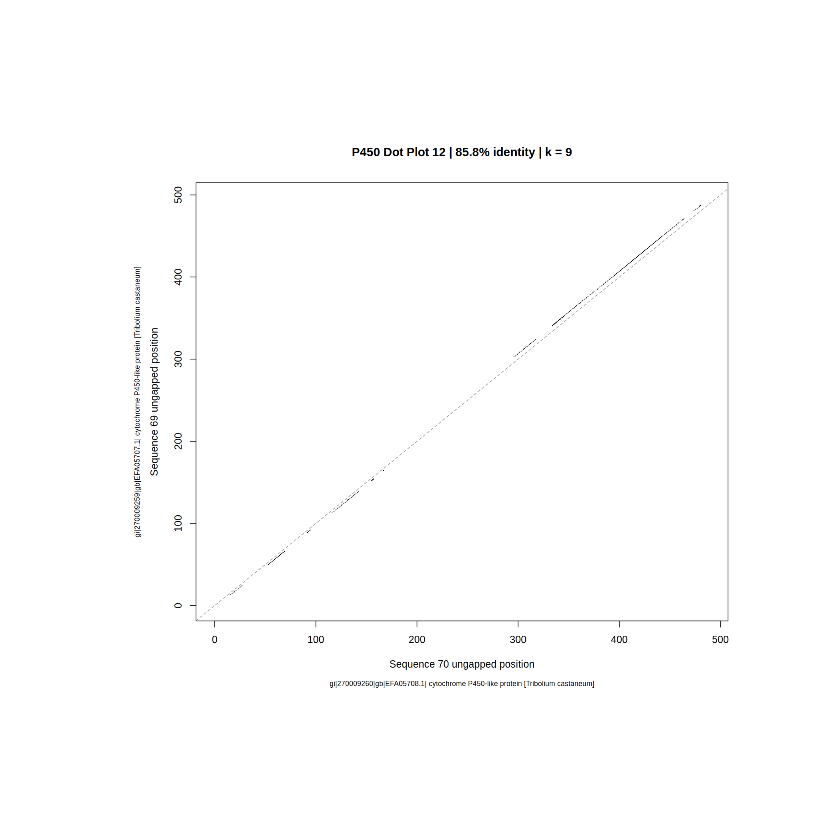


--------------------------------------------
DOT PLOT 14
--------------------------------------------


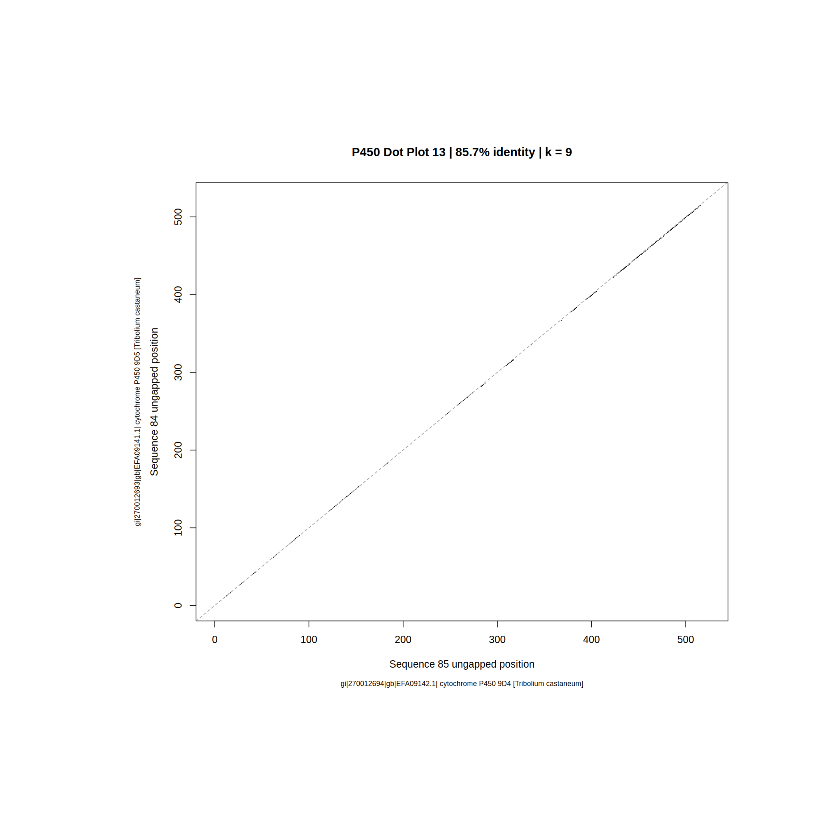


--------------------------------------------
DOT PLOT 15
--------------------------------------------


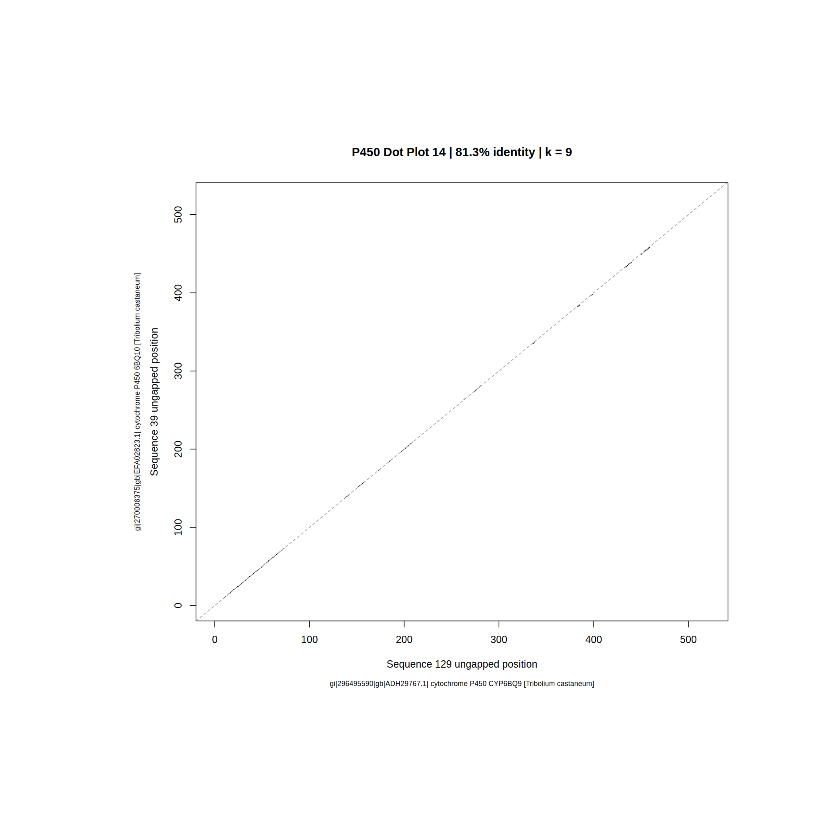


--------------------------------------------
DOT PLOT 16
--------------------------------------------


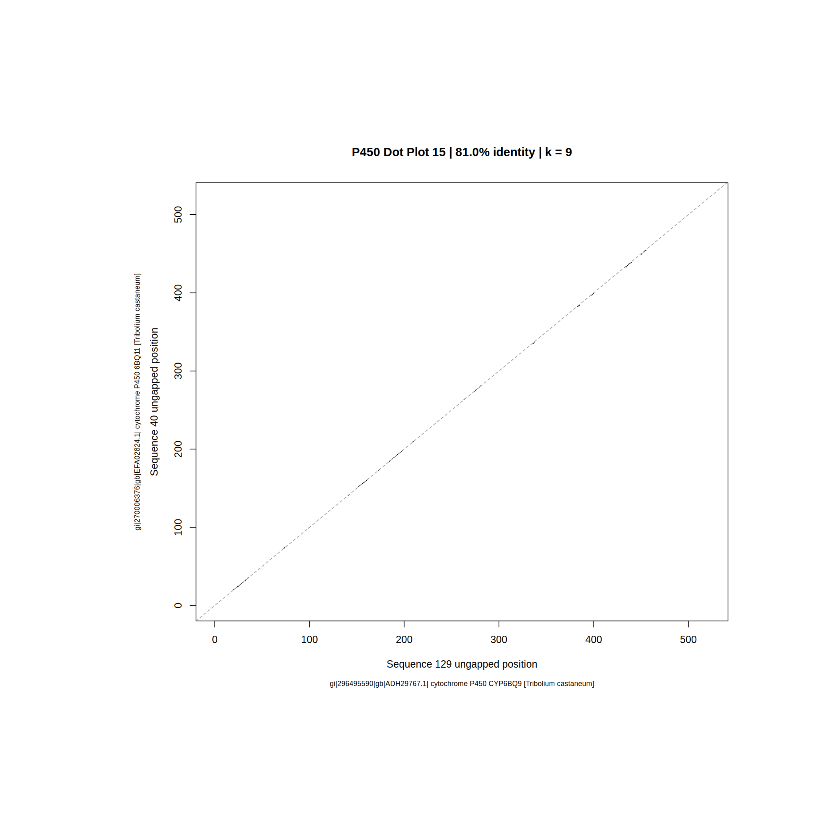


DONE

The 16 dot plots are saved separately here:
/content/dotplot_tiles_trimmed 

Files:
P450_dotplot_01.png 
P450_dotplot_02.png 
P450_dotplot_03.png 
P450_dotplot_04.png 
P450_dotplot_05.png 
P450_dotplot_06.png 
P450_dotplot_07.png 
P450_dotplot_08.png 
P450_dotplot_09.png 
P450_dotplot_10.png 
P450_dotplot_11.png 
P450_dotplot_12.png 
P450_dotplot_13.png 
P450_dotplot_14.png 
P450_dotplot_15.png 
P450_dotplot_16.png 

Trimmed alignment:
 /content/P450_trimmed_aln.fasta 


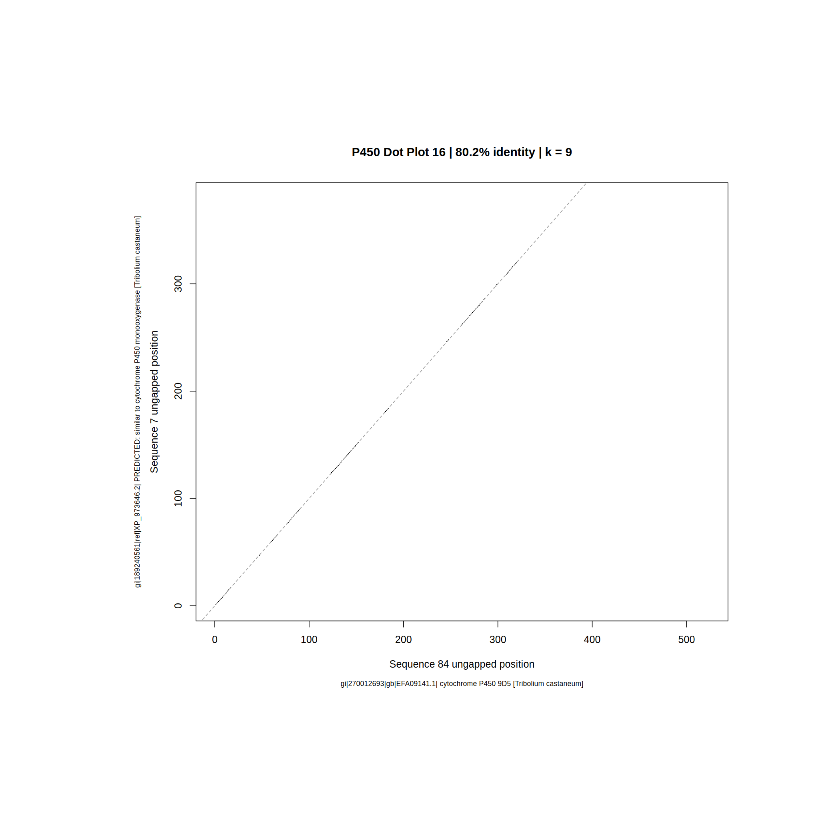

In [ ]:
# ============================================================
# P450 PROTEIN DOT PLOTS - SEPARATE LARGE IMAGES
# ============================================================
#
# Input:
#   /content/P450_aligned.fasta
#
# Output:
#   /content/P450_trimmed_aln.fasta
#   /content/dotplot_tiles_trimmed/
#
# The 16 dot plots are saved as SEPARATE PNG files.
# ============================================================


# ------------------------------------------------------------
# 1. Install/load packages
# ------------------------------------------------------------

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages(
    "BiocManager",
    repos = "https://cloud.r-project.org"
  )
}

if (!requireNamespace("Biostrings", quietly = TRUE)) {
  BiocManager::install(
    "Biostrings",
    ask = FALSE,
    update = FALSE
  )
}

library(Biostrings)


# ------------------------------------------------------------
# 2. File paths
# ------------------------------------------------------------

msa_path <- "/content/P450_aligned.fasta"

trimmed_path <- "/content/P450_trimmed_aln.fasta"

out_dir <- "/content/dotplot_tiles_trimmed"


# ------------------------------------------------------------
# 3. Parameters
# ------------------------------------------------------------

# k-mer size
#
# 9 = good starting point for protein sequences
#
# Smaller = more dots
# Larger = fewer, more specific dots

k <- 9


# Number of separate plots

number_to_plot <- 16


# Size of EACH individual image

plot_width <- 1600
plot_height <- 1400


# Resolution

plot_dpi <- 150


# ------------------------------------------------------------
# 4. Check input
# ------------------------------------------------------------

if (!file.exists(msa_path)) {

  stop(
    paste(
      "Input alignment not found:",
      msa_path
    )
  )
}


cat("============================================\n")
cat("P450 DOT-PLOT ANALYSIS\n")
cat("============================================\n\n")


# ------------------------------------------------------------
# 5. Read MAFFT alignment
# ------------------------------------------------------------

cat("Reading alignment...\n")

aln <- readAAStringSet(
  msa_path
)


N <- length(aln)

ids <- names(aln)

seqs <- as.character(aln)

alignment_length <- width(aln)[1]


cat(
  "Number of sequences:",
  N,
  "\n"
)

cat(
  "Alignment length:",
  alignment_length,
  "\n\n"
)


# ============================================================
# 6. Remove columns that are 100% gaps
# ============================================================

cat("Removing columns that contain only gaps...\n")


alignment_matrix <- as.matrix(aln)


keep_columns <- apply(
  alignment_matrix,
  2,
  function(x) {
    any(x != "-")
  }
)


trimmed_matrix <- alignment_matrix[
  ,
  keep_columns,
  drop = FALSE
]


trimmed_length <- ncol(
  trimmed_matrix
)


cat(
  "Original length:",
  alignment_length,
  "\n"
)

cat(
  "Trimmed length:",
  trimmed_length,
  "\n"
)

cat(
  "Columns removed:",
  alignment_length - trimmed_length,
  "\n\n"
)


# ------------------------------------------------------------
# 7. Save trimmed alignment
# ------------------------------------------------------------

trimmed_seqs <- apply(
  trimmed_matrix,
  1,
  paste0,
  collapse = ""
)


trimmed_aln <- AAStringSet(
  trimmed_seqs
)


names(trimmed_aln) <- ids


writeXStringSet(
  trimmed_aln,
  filepath = trimmed_path
)


cat(
  "Trimmed alignment saved:\n",
  trimmed_path,
  "\n\n"
)


# ============================================================
# 8. Calculate pairwise percent identity
# ============================================================

cat(
  "Calculating pairwise percent identities...\n"
)


calculate_identity <- function(
  sequence1,
  sequence2
) {

  A <- strsplit(
    sequence1,
    ""
  )[[1]]


  B <- strsplit(
    sequence2,
    ""
  )[[1]]


  # Compare only positions where neither sequence has a gap

  valid <- (
    A != "-" &
    B != "-"
  )


  denominator <- sum(valid)


  if (denominator == 0) {
    return(0)
  }


  matches <- sum(
    A[valid] == B[valid]
  )


  return(
    matches / denominator
  )
}


pairs <- data.frame(
  identity = numeric(0),
  sequence1 = integer(0),
  sequence2 = integer(0)
)


for (i in seq_len(N - 1)) {

  for (j in (i + 1):N) {

    pid <- calculate_identity(
      seqs[i],
      seqs[j]
    )


    pairs <- rbind(
      pairs,
      data.frame(
        identity = pid,
        sequence1 = i,
        sequence2 = j
      )
    )
  }
}


# ------------------------------------------------------------
# 9. Sort pairs from highest to lowest identity
# ------------------------------------------------------------

pairs <- pairs[
  order(
    pairs$identity,
    decreasing = TRUE
  ),
]


top_pairs <- head(
  pairs,
  number_to_plot
)


cat(
  "\n============================================\n"
)

cat(
  "TOP 16 SEQUENCE PAIRS\n"
)

cat(
  "============================================\n\n"
)


for (x in seq_len(nrow(top_pairs))) {

  i <- top_pairs$sequence1[x]

  j <- top_pairs$sequence2[x]


  cat(
    sprintf(
      "%02d: %.1f%% identity\n",
      x,
      top_pairs$identity[x] * 100
    )
  )

  cat(
    "    ",
    ids[i],
    "\n",
    sep = ""
  )

  cat(
    "    ",
    ids[j],
    "\n\n",
    sep = ""
  )
}


# ============================================================
# 10. Function to generate k-mer dot-plot points
# ============================================================

dotplot_points <- function(
  s1,
  s2,
  k
) {

  # Remove gaps

  s1u <- gsub(
    "-",
    "",
    s1
  )


  s2u <- gsub(
    "-",
    "",
    s2
  )


  chars1 <- strsplit(
    s1u,
    ""
  )[[1]]


  chars2 <- strsplit(
    s2u,
    ""
  )[[1]]


  L1 <- length(chars1)

  L2 <- length(chars2)


  # Check sequence lengths

  if (
    L1 < k ||
    L2 < k
  ) {

    return(
      list(
        x = numeric(0),
        y = numeric(0),
        length1 = L1,
        length2 = L2
      )
    )
  }


  # ----------------------------------------------------------
  # Index all k-mers in sequence 2
  # ----------------------------------------------------------

  index <- list()


  for (j in seq_len(L2 - k + 1)) {

    km <- paste0(
      chars2[
        j:(j + k - 1)
      ],
      collapse = ""
    )


    if (is.null(index[[km]])) {

      index[[km]] <- j

    } else {

      index[[km]] <- c(
        index[[km]],
        j
      )
    }
  }


  # ----------------------------------------------------------
  # Search sequence 1 against sequence 2
  # ----------------------------------------------------------

  xs <- numeric(0)

  ys <- numeric(0)


  for (i in seq_len(L1 - k + 1)) {

    km <- paste0(
      chars1[
        i:(i + k - 1)
      ],
      collapse = ""
    )


    matching_positions <- index[[km]]


    if (!is.null(matching_positions)) {

      xs <- c(
        xs,
        matching_positions
      )


      ys <- c(
        ys,
        rep(
          i,
          length(matching_positions)
        )
      )
    }
  }


  return(
    list(
      x = xs,
      y = ys,
      length1 = L1,
      length2 = L2
    )
  )
}


# ============================================================
# 11. Create output directory
# ============================================================

if (!dir.exists(out_dir)) {

  dir.create(
    out_dir,
    recursive = TRUE
  )
}


# ============================================================
# 12. Generate 16 SEPARATE dot plots
# ============================================================

cat(
  "\n============================================\n"
)

cat(
  "GENERATING SEPARATE DOT PLOTS\n"
)

cat(
  "============================================\n\n"
)


plot_files <- character(
  nrow(top_pairs)
)


for (idx in seq_len(nrow(top_pairs))) {


  # ----------------------------------------------------------
  # Get pair information
  # ----------------------------------------------------------

  i <- top_pairs$sequence1[idx]

  j <- top_pairs$sequence2[idx]

  pid <- top_pairs$identity[idx]


  cat(
    "Creating plot ",
    idx,
    " of ",
    nrow(top_pairs),
    "...\n",
    sep = ""
  )


  # ----------------------------------------------------------
  # Generate dot points
  # ----------------------------------------------------------

  points <- dotplot_points(
    seqs[i],
    seqs[j],
    k
  )


  x <- points$x

  y <- points$y

  length1 <- points$length1

  length2 <- points$length2


  # ----------------------------------------------------------
  # Create clean filename
  # ----------------------------------------------------------

  output_file <- file.path(
    out_dir,
    sprintf(
      "P450_dotplot_%02d.png",
      idx
    )
  )


  # ----------------------------------------------------------
  # Create large PNG
  # ----------------------------------------------------------

  png(
    filename = output_file,
    width = plot_width,
    height = plot_height,
    res = plot_dpi
  )


  par(
    mar = c(
      6,
      6,
      5,
      3
    )
  )


  # ----------------------------------------------------------
  # Plot
  # ----------------------------------------------------------

  if (length(x) > 0) {

    plot(
      x,
      y,
      type = "p",
      pch = 16,
      cex = 0.20,
      col = "black",

      xlim = c(
        1,
        length2
      ),

      ylim = c(
        1,
        length1
      ),

      xlab = paste0(
        "Sequence ",
        j,
        " ungapped position"
      ),

      ylab = paste0(
        "Sequence ",
        i,
        " ungapped position"
      ),

      main = paste0(
        "P450 Dot Plot ",
        idx,
        " | ",
        sprintf(
          "%.1f",
          pid * 100
        ),
        "% identity | k = ",
        k
      )
    )


    # Add a diagonal reference line
    #
    # This is useful for visually identifying
    # similarity along the sequence.

    abline(
      a = 0,
      b = 1,
      col = "gray60",
      lty = 2,
      lwd = 1
    )


  } else {

    plot(
      1,
      1,
      type = "n",
      xlab = paste0(
        "Sequence ",
        j
      ),
      ylab = paste0(
        "Sequence ",
        i
      ),
      main = paste0(
        "P450 Dot Plot ",
        idx,
        " | ",
        sprintf(
          "%.1f",
          pid * 100
        ),
        "% identity | k = ",
        k
      )
    )


    text(
      1,
      1,
      "No matching k-mers"
    )
  }


  # ----------------------------------------------------------
  # Add sequence names below/above plot
  # ----------------------------------------------------------

  mtext(
    ids[i],
    side = 2,
    line = 4.5,
    cex = 0.7
  )


  mtext(
    ids[j],
    side = 1,
    line = 4.5,
    cex = 0.7
  )


  # Close PNG

  dev.off()


  plot_files[idx] <- output_file


  cat(
    "Saved -> ",
    output_file,
    "\n\n",
    sep = ""
  )
}


# ============================================================
# 13. Display each plot separately in Colab
# ============================================================

cat(
  "\n============================================\n"
)

cat(
  "DISPLAYING INDIVIDUAL DOT PLOTS\n"
)

cat(
  "============================================\n\n"
)


# The following displays each PNG separately.
# They are NOT combined into a grid.

for (idx in seq_along(plot_files)) {

  cat(
    "\n--------------------------------------------\n"
  )

  cat(
    "DOT PLOT ",
    idx,
    "\n",
    sep = ""
  )

  cat(
    "--------------------------------------------\n"
  )


  # Display image in R/Colab

  img <- png::readPNG(
    plot_files[idx]
  )


  plot.new()

  rasterImage(
    as.raster(img),
    0,
    0,
    1,
    1
  )
}


# ============================================================
# 14. Final output information
# ============================================================

cat(
  "\n============================================\n"
)

cat(
  "DONE\n"
)

cat(
  "============================================\n\n"
)


cat(
  "The 16 dot plots are saved separately here:\n"
)

cat(
  out_dir,
  "\n\n"
)


cat(
  "Files:\n"
)


for (f in plot_files) {

  cat(
    basename(f),
    "\n"
  )
}


cat(
  "\nTrimmed alignment:\n",
  trimmed_path,
  "\n"
)
